### 1. Iris Dataset 
(a) Write your own Python program for KNN and classify Iris dataset  
(b) Classify using KNeighborsClassifier (sklearn)  
(c) Find error for values of k from 1 to 10

## (a) Write your own Python program for KNN and classify Iris dataset

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from collections import Counter

In [2]:
# Load iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [3]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
# split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
# distance function (Euclidean distance)
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [7]:
# knn class
class KNN:
    def __init__(self, k=3):
        self.k = k

    # train (store dataset)
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    # predict for multiple samples
    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    # predict single sample
    def _predict(self, x):
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # find k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [8]:
# use model
model = KNN(k=3)
model.fit(X_train, y_train)

In [9]:
predictions = model.predict(X_test)
np.array(predictions)

array([2, 1, 0, 0, 1, 1, 1, 0, 2, 0, 2, 1, 1, 0, 0, 0, 0, 2, 0, 1, 2, 1,
       1, 2, 1, 2, 2, 1, 0, 1])

In [10]:
# Calculate accuracy
accuracy = np.sum(predictions == y_test) / len(y_test)
"Accuracy:", accuracy

('Accuracy:', 0.9666666666666667)

In [11]:
import pandas as pd

data = []

# labels from predictions
for i in range(len(predictions)):
    predicted_label = iris.target_names[predictions[i]]
    actual_label = iris.target_names[y_test[i]]

    data.append([i+1, predicted_label, actual_label])

pred_df = pd.DataFrame(data, columns=["Sample", "Predicted", "Actual"])
pred_df

,Sample,Predicted,Actual
0,1,virginica,virginica
1,2,versicolor,versicolor
2,3,setosa,setosa
3,4,setosa,setosa
4,5,versicolor,versicolor
5,6,versicolor,versicolor
6,7,versicolor,versicolor
7,8,setosa,setosa
8,9,virginica,virginica
9,10,setosa,setosa


## (b) Classify using KNeighborsClassifier (sklearn)

In [12]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [14]:
model = KNeighborsClassifier(n_neighbors=3)

In [15]:
model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
y_pred = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [28]:
np.array(y_pred)

array([2, 2, 0, 0, 2, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 2, 2, 2, 1,
       1, 1, 1, 2, 0, 1, 1, 0])

## (c) Find error for values of k from 1 to 10

In [29]:
import matplotlib.pyplot as plt

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [31]:
# store error values
error = []

# loop for k from 1 to 10
for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    err = 1 - accuracy_score(y_test, y_pred)
    error.append(err)


In [32]:
for i in range(10):
    print(f"k = {i+1}, Err = {error[i]}")

k = 1, Err = 0.033333333333333326
k = 2, Err = 0.06666666666666665
k = 3, Err = 0.033333333333333326
k = 4, Err = 0.033333333333333326
k = 5, Err = 0.033333333333333326
k = 6, Err = 0.033333333333333326
k = 7, Err = 0.0
k = 8, Err = 0.0
k = 9, Err = 0.0
k = 10, Err = 0.0


### i think k = 7 is optimal

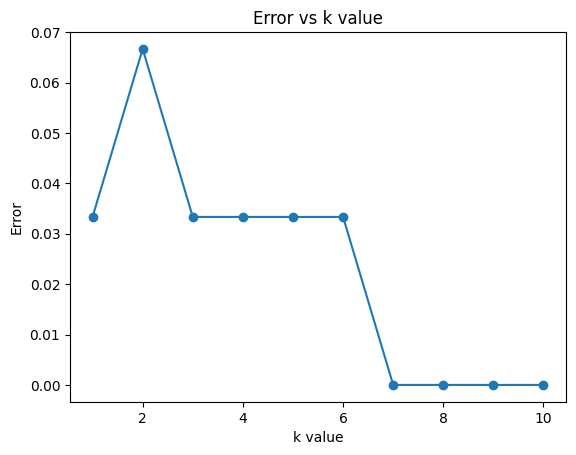

In [33]:
# plot graph
plt.plot(range(1, 11), error, marker='o')
plt.xlabel('k value')
plt.ylabel('Error')
plt.title('Error vs k value')
plt.show()